In [24]:
import sys
import os

# Détection automatique de la racine du projet
# On remonte d'un niveau depuis le dossier 'notebooks'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Ajout au path pour pouvoir faire "from src..."
if project_root not in sys.path:
    sys.path.append(project_root)

# Définition des chemins absolus
DATA_RAW = os.path.join(project_root, "data", "raw")
DATA_PROCESSED = os.path.join(project_root, "data", "processed")
GEO_PATH = os.path.join(project_root, "geo")

print(f"Système configuré. Racine : {project_root}")

Système configuré. Racine : c:\Users\valen\OneDrive\Documents\GitHub\Projet-de-Statapp---WFP-


# Fonctions

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_optimal_lag(df, state_name, target_var='inadequate', climate_var='WSI', max_lag=6):
    """
    Computes the optimal time lag between a climate variable and food insecurity,
    then displays the correlation results and the corresponding dual-axis plot.
    """
    # 1. Data preparation for the specific state
    # Handles both potential column names for administrative boundaries
    col_state = 'NAME_1' if 'NAME_1' in df.columns else 'ADM1_NAME'
    df_state = df[df[col_state] == state_name].sort_values('time').copy()
    
    if df_state.empty:
        print(f"Error: No data found for state: {state_name}")
        return None

    print(f"--- LAG ANALYSIS: {climate_var} vs {target_var} ({state_name}) ---")
    
    # 2. Iterating through lags to compute Pearson correlations
    lags = list(range(max_lag + 1))
    corrs = []
    
    for lag in lags:
        # Dynamic column selection: uses the raw variable for lag 0, otherwise looks for the lag column
        col_name = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        
        if col_name in df_state.columns:
            # Drop NaN values to ensure a clean correlation calculation
            valid_data = df_state[[target_var, col_name]].dropna()
            if len(valid_data) > 2:
                correlation = valid_data[target_var].corr(valid_data[col_name])
                corrs.append(correlation)
                print(f"  Lag {lag} month(s): Correlation = {correlation:.3f}")
            else:
                corrs.append(0)
        else:
            corrs.append(0)
            
    # 3. Identify the best Lag based on the highest absolute correlation value
    best_idx = np.argmax([abs(c) for c in corrs])
    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]
    
    print(f"\nRESULT: Optimal delay is {best_lag} month(s) (Corr: {best_corr:.3f})")

    # 4. Visualization logic
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Left Axis: Food Insecurity (Target)
    color_target = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f"{target_var} (%)", color=color_target, fontweight='bold')
    ax1.plot(df_state['time'], df_state[target_var], color=color_target, linewidth=2, label=f'{target_var} (Actual)')
    ax1.tick_params(axis='y', labelcolor=color_target)
    ax1.grid(alpha=0.3)

    # Right Axis: Climate Variable at the optimal lag
    ax2 = ax1.twinx()
    color_climate = 'tab:blue'
    best_col_name = climate_var if best_lag == 0 else f'{climate_var}_Lag_{best_lag}'
    
    ax2.set_ylabel(f"{climate_var} (Lag {best_lag})", color=color_climate, fontweight='bold')
    ax2.fill_between(df_state['time'], df_state[best_col_name], color=color_climate, alpha=0.2, label=f"{climate_var} (t-{best_lag})")
    ax2.tick_params(axis='y', labelcolor=color_climate)
    
    plt.title(f"Impact of {climate_var} on {target_var} in {state_name} (Best Lag: {best_lag} months)", fontsize=14)
    
    # Merge legends from both axes into a single box
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True)
    
    plt.tight_layout()
    plt.show()
    
    return {"state": state_name, "best_lag": best_lag, "correlation": best_corr}

In [26]:
filepath = '../data/processed/NIGERIA_WFP_ENGINEERED.csv'
df = pd.read_csv(filepath)

#  Official geopolitical mapping
zones = {
    'North': ['Borno', 'Kano', 'Kaduna', 'Katsina', 'Sokoto', 'Kebbi', 'Zamfara', 'Jigawa', 'Yobe', 'Adamawa', 'Bauchi', 'Gombe', 'Taraba', 'Niger', 'Plateau', 'Nasarawa', 'Benue', 'Kogi', 'Kwara', 'Federal Capital Territory'],
    'South': ['Lagos', 'Ogun', 'Oyo', 'Osun', 'Ekiti', 'Ondo', 'Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo', 'Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers']
}

# Mapping function for your DataFrame
df['geopolitical_region'] = df['NAME_1'].apply(lambda x: 'North' if x in zones['North'] else 'South')

# North and South separation

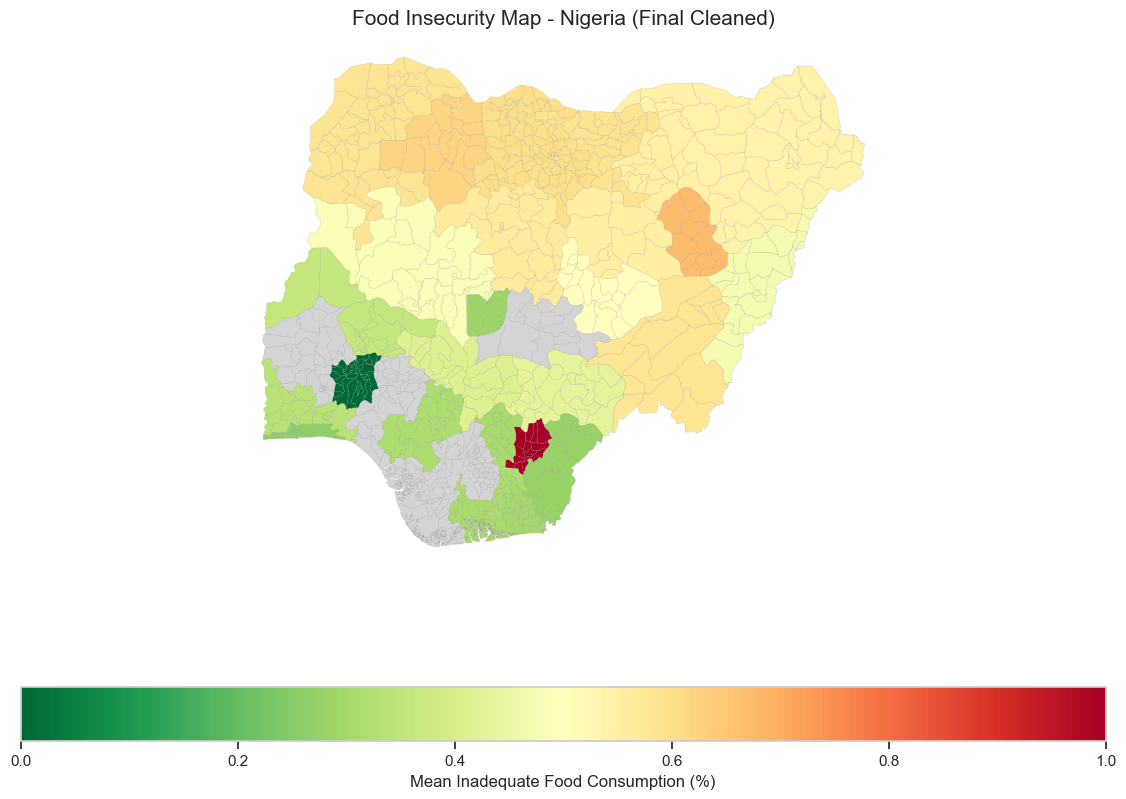

States still in grey: ['Anambra' 'Bayelsa' 'Delta' 'Ekiti' 'Imo' 'Nasarawa' 'Ondo' 'Oyo']


In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the geographical shapes
geo_path = '../geo/gadm41_NGA_2.json' 
gdf = gpd.read_file(geo_path)

# 2. STRATEGY: Remove all spaces and special characters from BOTH datasets
# This is the safest way to ensure a match
def clean_names(name):
    return str(name).replace(' ', '').replace('-', '').replace('_', '')

# Clean the GeoJSON names
gdf['NAME_1_clean'] = gdf['NAME_1'].apply(clean_names)

# Clean the DataFrame names and handle the 'Abuja' exception
df['NAME_1'] = df['NAME_1'].replace({'Abuja': 'Federal Capital Territory'})
df['NAME_1_clean'] = df['NAME_1'].apply(clean_names)

# 3. Re-calculate stats with cleaned names
state_stats = df.groupby('NAME_1_clean')['inadequate'].mean().reset_index()

# 4. Merge using the cleaned columns
merged = gdf.merge(state_stats, on='NAME_1_clean', how='left')

# 5. Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

merged.plot(column='inadequate', 
            cmap='RdYlGn_r', 
            linewidth=0.1, # Thin lines because it's Admin 2
            ax=ax, 
            edgecolor='0.5', 
            missing_kwds={'color': 'lightgrey', 'label': 'No survey data'}, 
            legend=True,
            legend_kwds={'label': "Mean Inadequate Food Consumption (%)", 'orientation': "horizontal"})

ax.set_title('Food Insecurity Map - Nigeria (Final Cleaned)', fontsize=15)
ax.axis('off')
plt.show()

# 6. Check if holes remain (other than the 7 states without data)
missing_after = merged[merged['inadequate'].isna()]['NAME_1'].unique()
print("States still in grey:", missing_after)

In [28]:
# Check which states from the map have no data associated
missing_states = merged[merged['inadequate'].isna()]['NAME_1'].unique()

if len(missing_states) > 0:
    print(f"States with no data (White holes): {missing_states}")
else:
    print("No missing data for the states present in the GeoJSON.")

States with no data (White holes): ['Anambra' 'Bayelsa' 'Delta' 'Ekiti' 'Imo' 'Nasarawa' 'Ondo' 'Oyo']


In [29]:
# List names in your stats vs names in the GeoJSON
print("Names in CSV stats:", sorted(df['NAME_1'].unique()))
print("\nNames in GeoJSON:", sorted(gdf['NAME_1'].unique()))

Names in CSV stats: ['Abia', 'Adamawa', 'Akwa Ibom', 'Bauchi', 'Benue', 'Borno', 'Cross River', 'Ebonyi', 'Edo', 'Enugu', 'Federal Capital Territory', 'Gombe', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nassarawa', 'Niger', 'Ogun', 'Osun', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara']

Names in GeoJSON: ['Abia', 'Adamawa', 'AkwaIbom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue', 'Borno', 'CrossRiver', 'Delta', 'Ebonyi', 'Edo', 'Ekiti', 'Enugu', 'FederalCapitalTerritory', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara']


### Note on Data Coverage and Spatial Constraints

The geographical visualization of food insecurity across Nigeria reveals certain "data gaps," specifically in the following seven states: **Anambra, Bayelsa, Delta, Ekiti, Imo, Ondo, and Oyo**. 

These areas appear in grey on the map due to their absence in the original World Food Programme (WFP) datasets used for this study (`NIGERIA_WFP_ADMIN1.csv` and the processed versions). 

#### Methodological Explanation:
1. **Targeted Monitoring**: WFP's mobile Vulnerability Analysis and Mapping (mVAM) typically prioritizes regions with higher risks of acute food insecurity. Historically, this focuses on the **North-East** (due to conflict-related instability) and the **North-West/Sahelian belt** (due to high climatic vulnerability).
2. **Geographical Focus**: Most of the missing states are located in the **South** and **South-West** zones. While these regions face economic challenges, they are often characterized by different food system dynamics (market-driven) and were not covered by the high-frequency survey rounds available in this specific dataset.
3. **Implications for Analysis**: The absence of these states represents a **spatial coverage bias**. Consequently, the comparative analysis between "North" and "South" is conducted using the available representative states in the South (such as Lagos, Rivers, or Cross River), which still allow for a robust identification of diverging food security trends between the two macro-regions.

This limitation is documented as a constraint of the secondary data source and highlights the need for expanded sub-national monitoring in future research.

C:\Users\valen\AppData\Local\Temp\ipykernel_744\4019988763.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


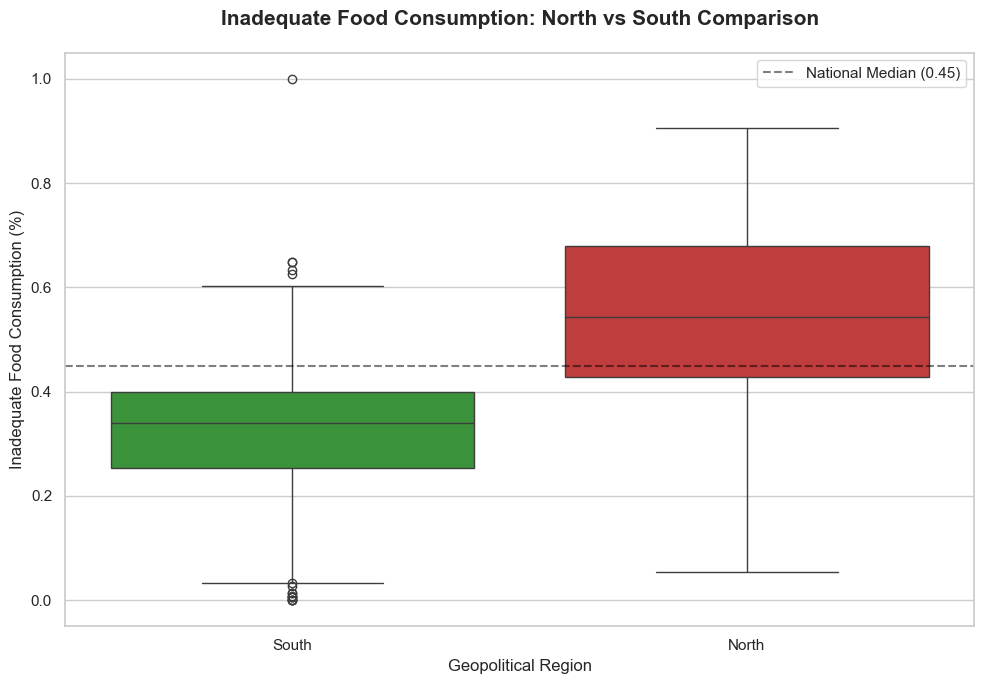

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuration of the visual theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# 2. Creating the boxplot
# We use the 'geopolitical_region' column created earlier
# Comparing the distribution of the 'inadequate' variable
ax = sns.boxplot(
    data=df, 
    x='geopolitical_region', 
    y='inadequate', 
    palette={'North': 'tab:red', 'South': 'tab:green'},
    order=['South', 'North'] # Ordering for a clear left-to-right comparison
)

# 3. Adding titles and labels
plt.title('Inadequate Food Consumption: North vs South Comparison', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Geopolitical Region', fontsize=12)
plt.ylabel('Inadequate Food Consumption (%)', fontsize=12)

# 4. Adding a horizontal line for the national median (optional but useful)
national_median = df['inadequate'].median()
plt.axhline(national_median, color='black', linestyle='--', alpha=0.5, label=f'National Median ({national_median:.2f})')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

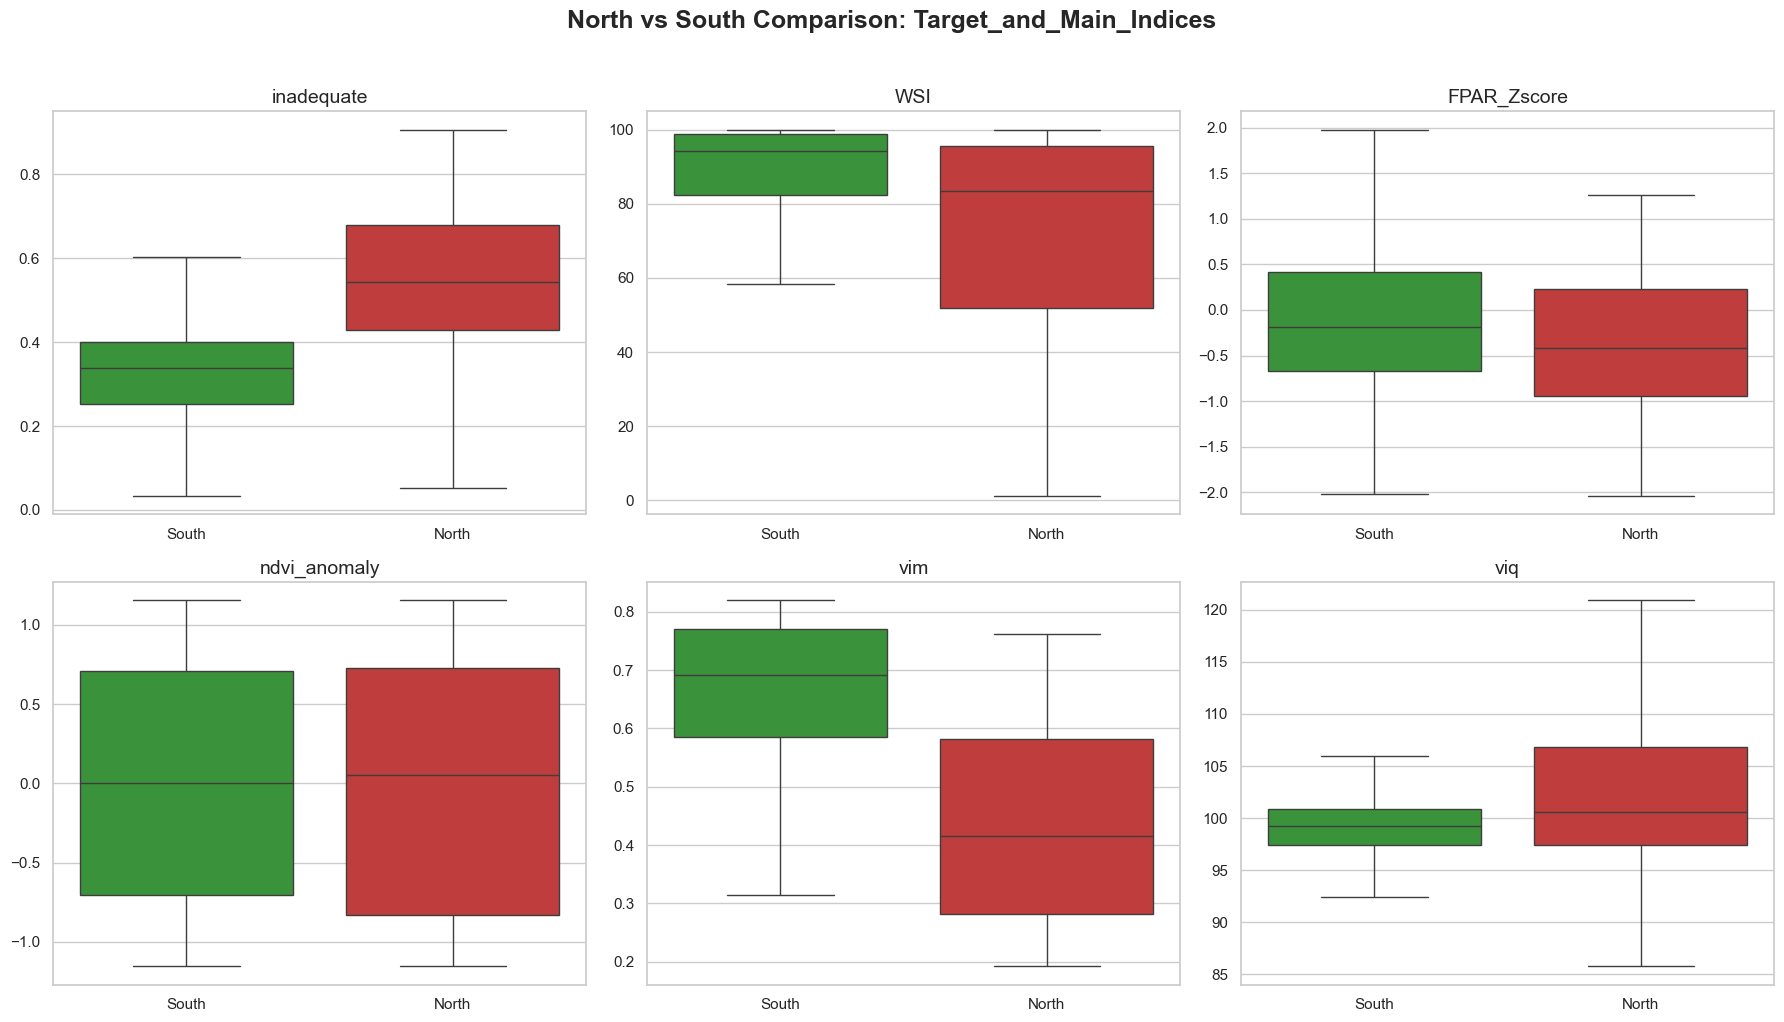

C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

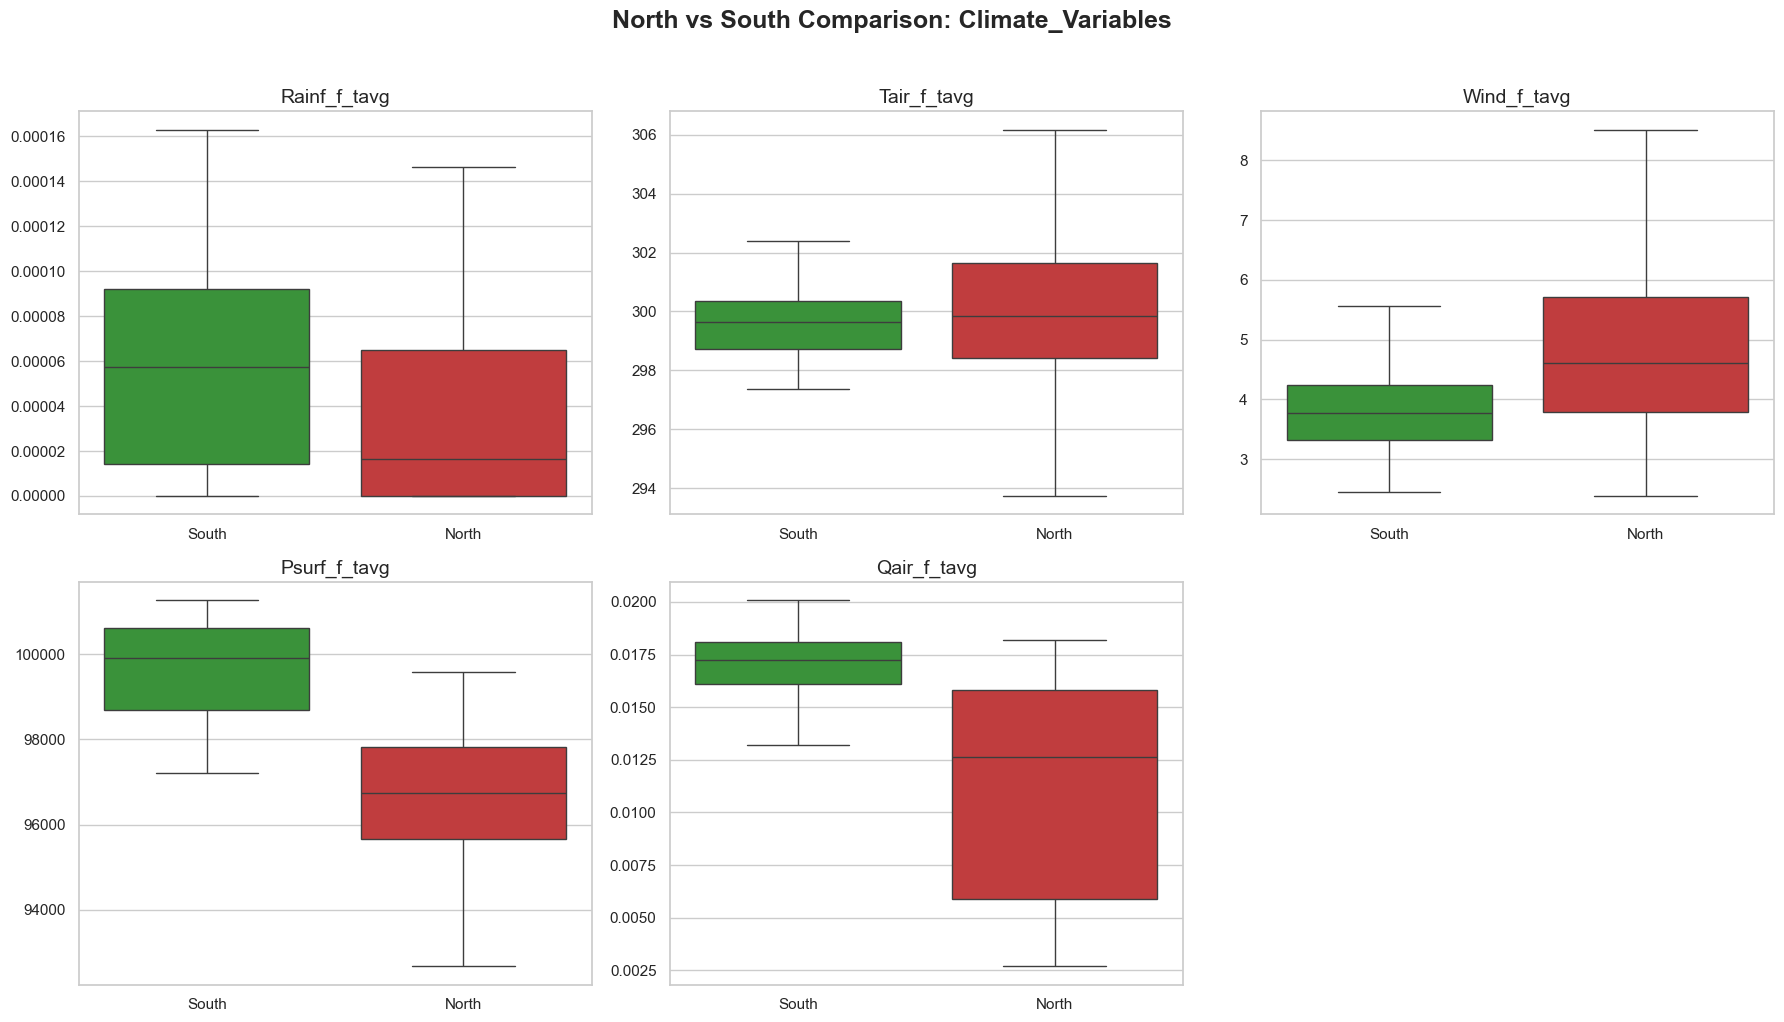

C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

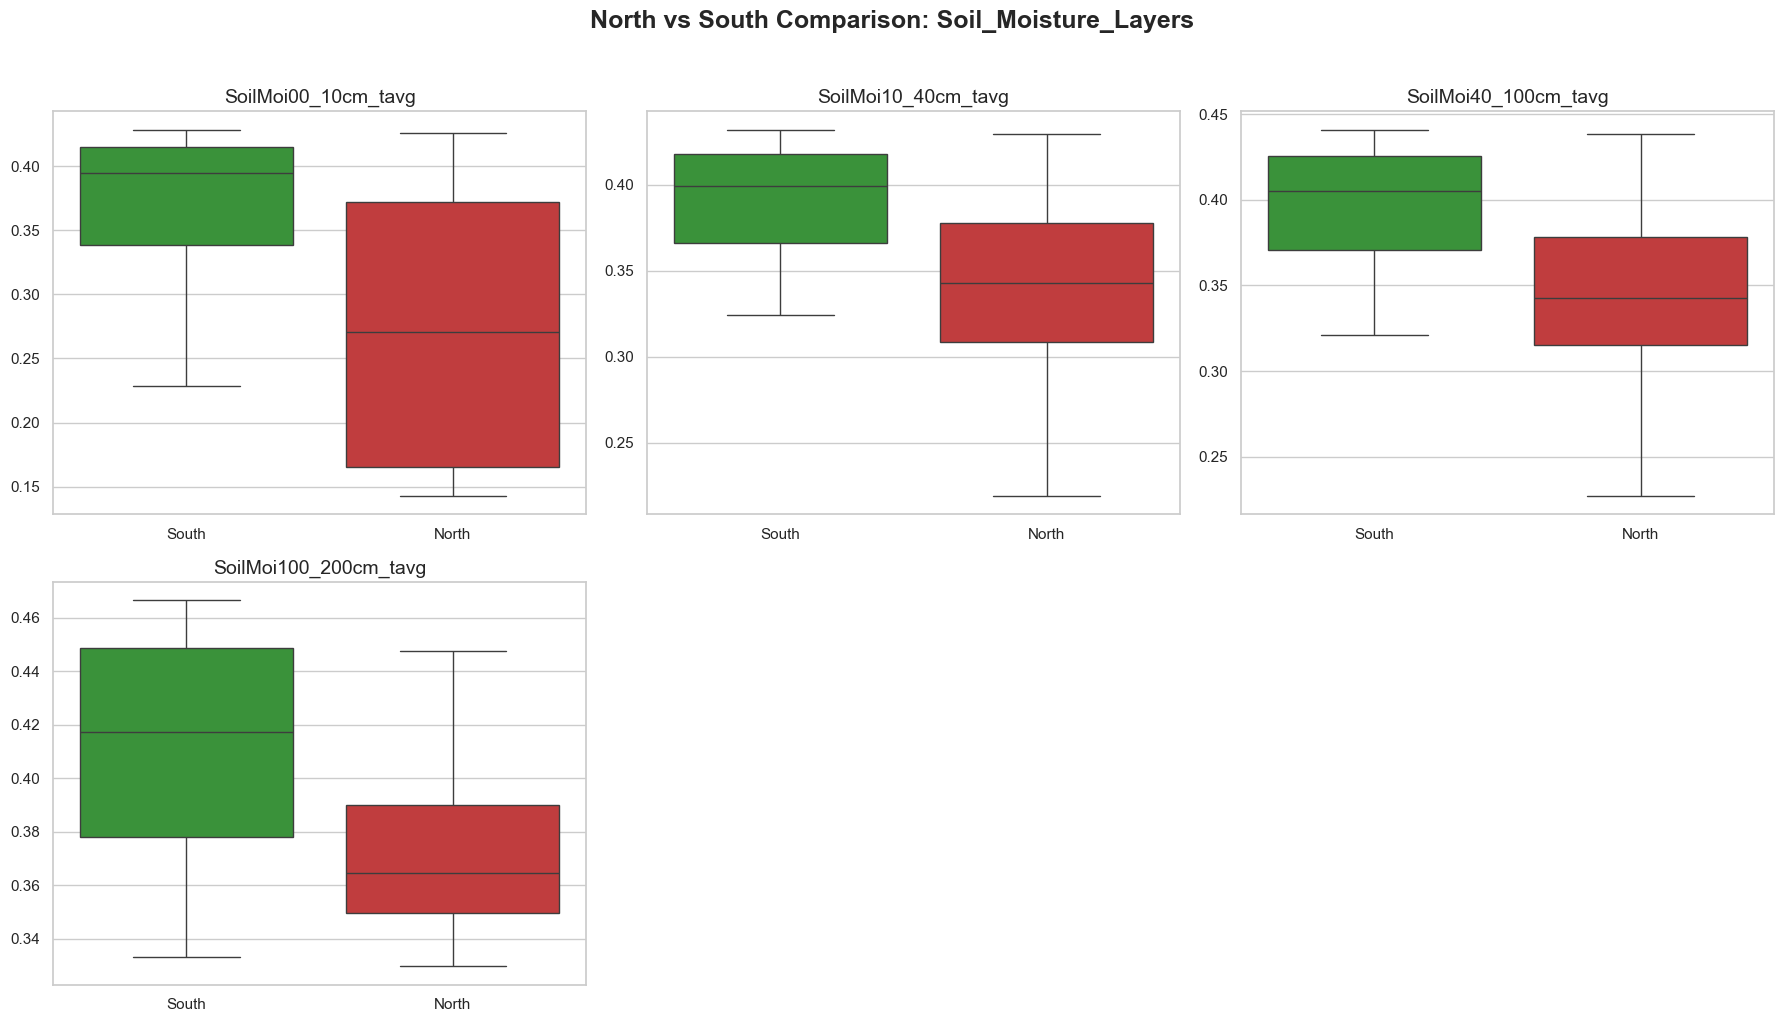

C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

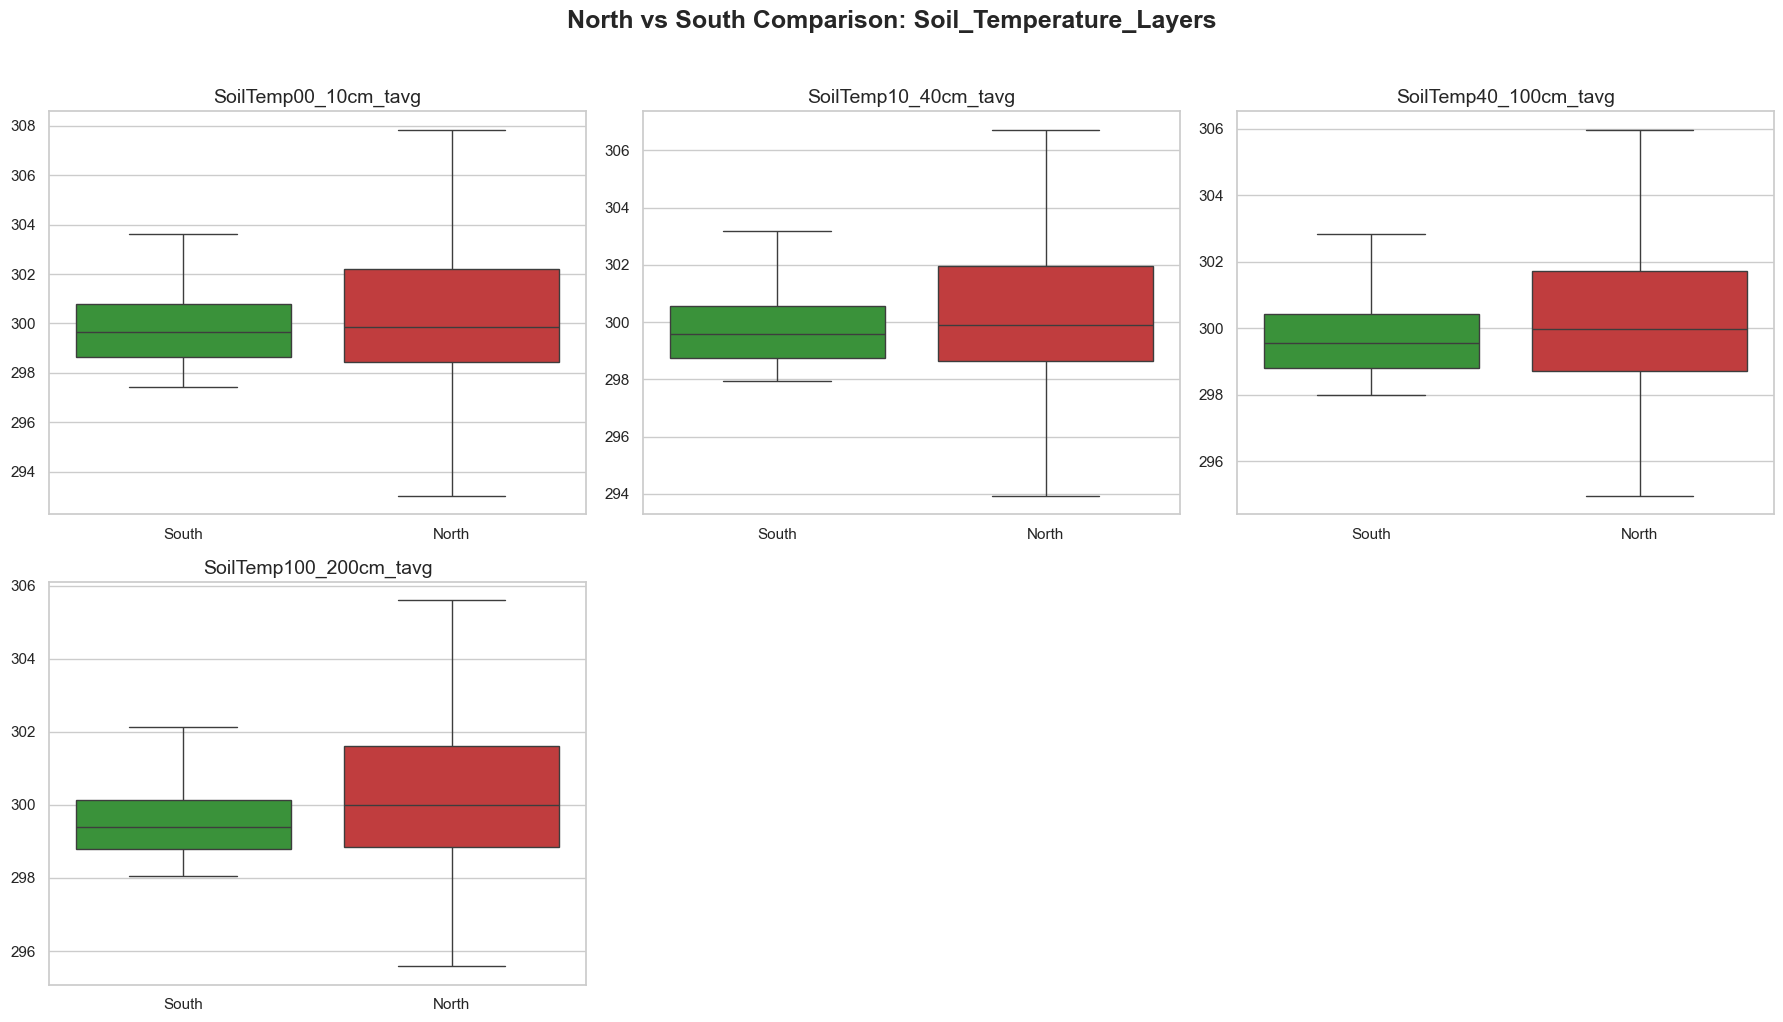

C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

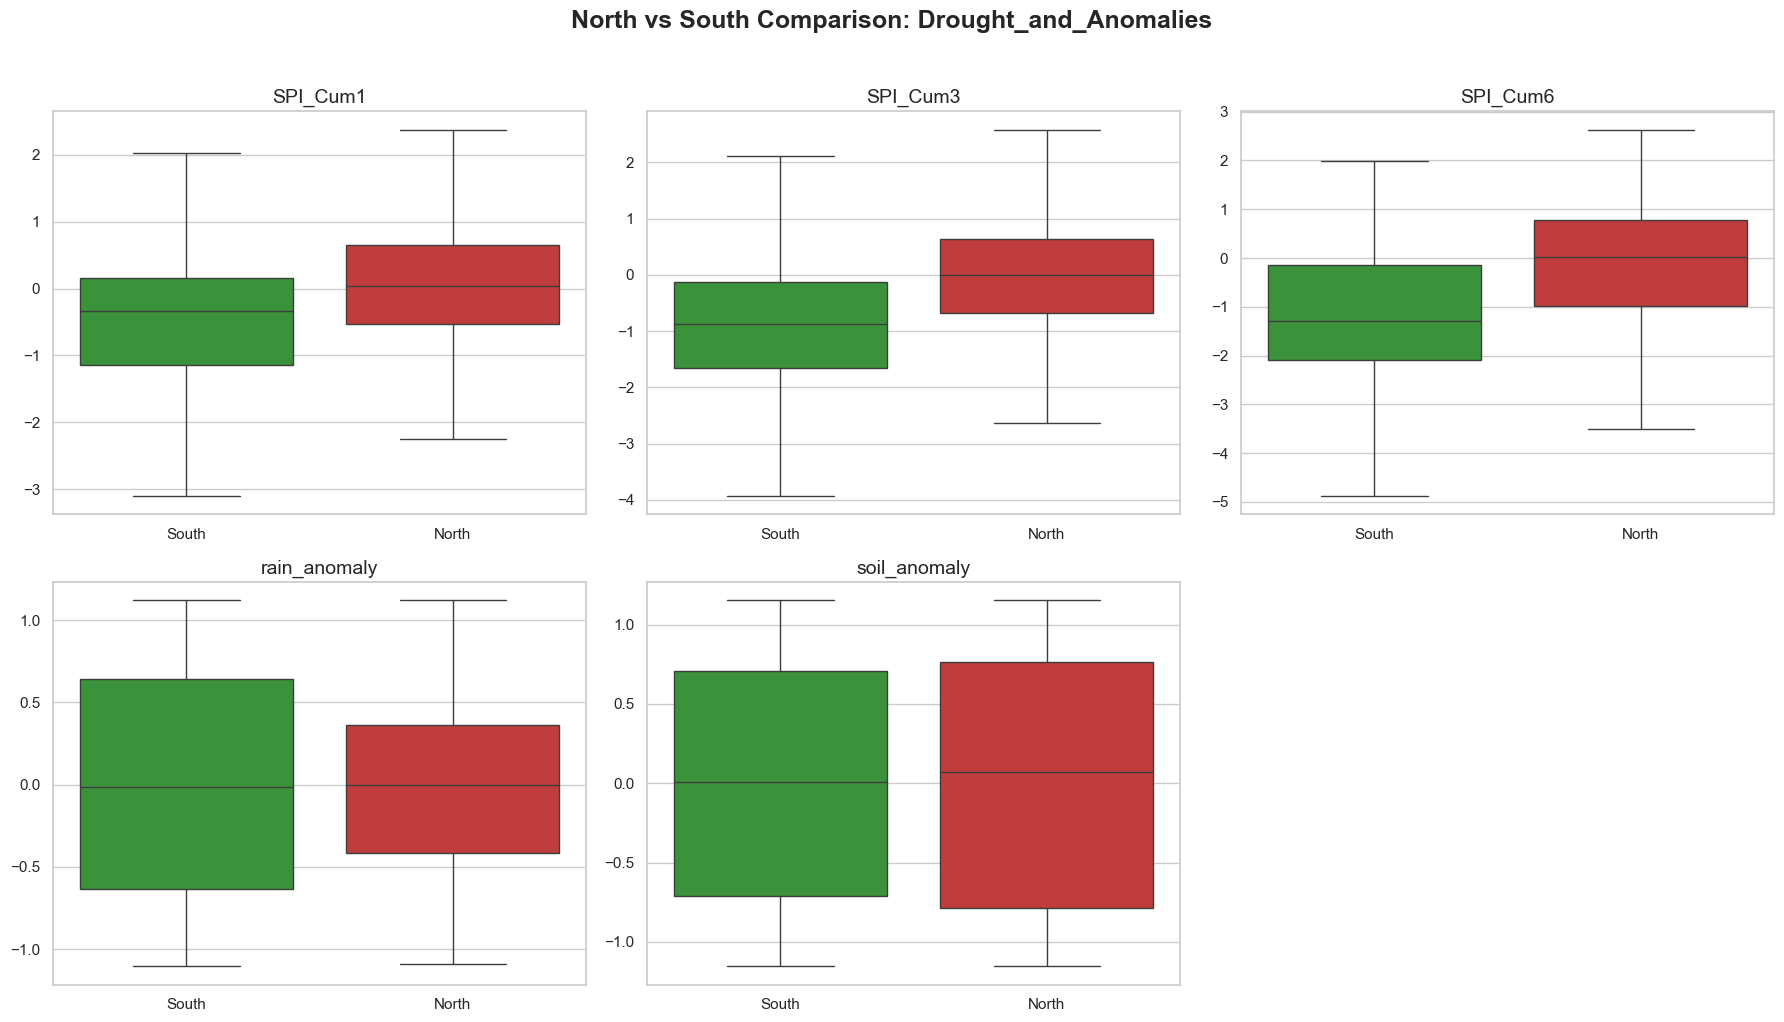

C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\valen\AppData\Local\Temp\ipykernel_744\2050225617.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

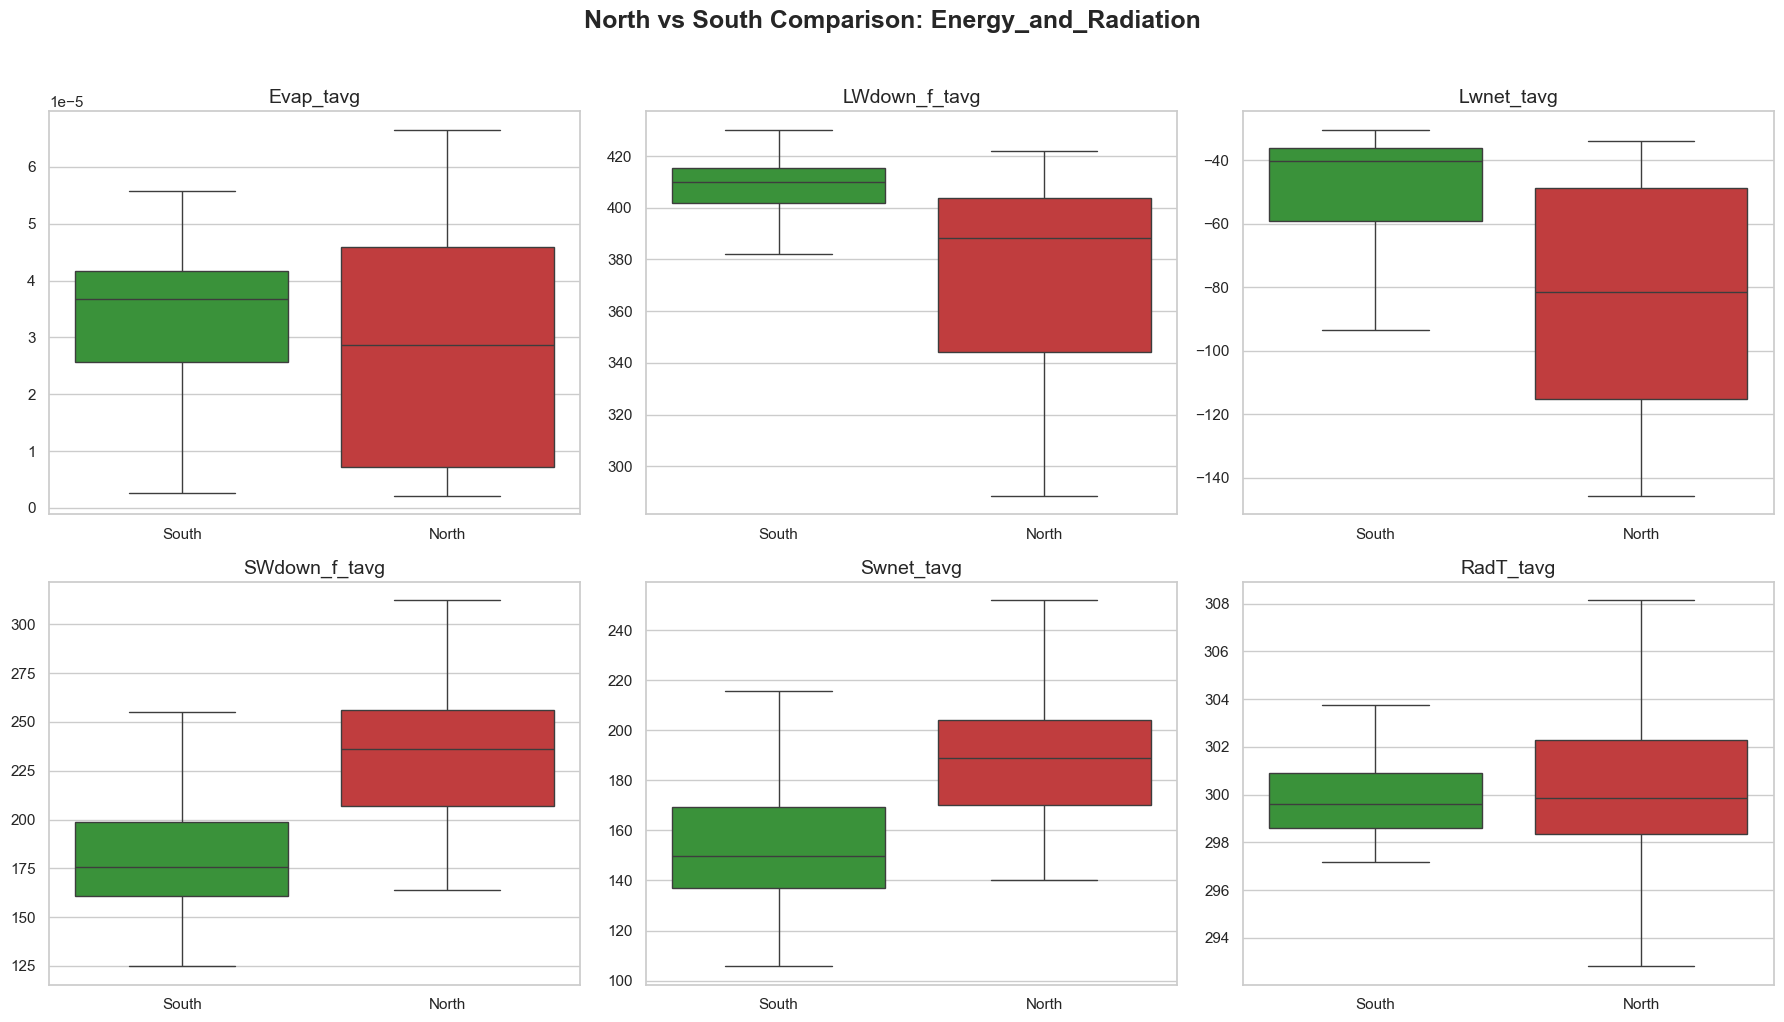

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Define logical groups of variables for the analysis
# This avoids plotting metadata or coordinates and groups related features
variable_groups = {
    "Target_and_Main_Indices": ['inadequate', 'WSI', 'FPAR_Zscore', 'ndvi_anomaly', 'vim', 'viq'],
    "Climate_Variables": ['Rainf_f_tavg', 'Tair_f_tavg', 'Wind_f_tavg', 'Psurf_f_tavg', 'Qair_f_tavg'],
    "Soil_Moisture_Layers": ['SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg', 'SoilMoi40_100cm_tavg', 'SoilMoi100_200cm_tavg'],
    "Soil_Temperature_Layers": ['SoilTemp00_10cm_tavg', 'SoilTemp10_40cm_tavg', 'SoilTemp40_100cm_tavg', 'SoilTemp100_200cm_tavg'],
    "Drought_and_Anomalies": ['SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6', 'rain_anomaly', 'soil_anomaly'],
    "Energy_and_Radiation": ['Evap_tavg', 'LWdown_f_tavg', 'Lwnet_tavg', 'SWdown_f_tavg', 'Swnet_tavg', 'RadT_tavg']
}

# 2. General plotting function
def plot_grouped_boxplots(df, groups):
    sns.set_theme(style="whitegrid")
    
    for group_name, vars in groups.items():
        # Filter available columns to avoid errors
        available_vars = [v for v in vars if v in df.columns]
        if not available_vars:
            continue
            
        num_vars = len(available_vars)
        cols = 3
        rows = math.ceil(num_vars / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
        fig.suptitle(f'North vs South Comparison: {group_name}', fontsize=18, fontweight='bold', y=1.02)
        
        axes = axes.flatten()
        
        for i, var in enumerate(available_vars):
            sns.boxplot(
                data=df, 
                x='geopolitical_region', 
                y=var, 
                ax=axes[i], 
                palette={'North': 'tab:red', 'South': 'tab:green'},
                order=['South', 'North'],
                showfliers=False # Hidden for better clarity of distributions
            )
            axes[i].set_title(f'{var}', fontsize=14)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')
            
        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout()
        plt.show()

# 3. Execution
plot_grouped_boxplots(df, variable_groups)

# Feature Selection

In Phase 2, an exhaustive feature space was generated, including simple lags (1 to 6 months), rolling means (1, 3, 6 months), and standardized cumulative indices (SPI, WSI). 

To prevent **multicollinearity** and optimize model interpretability in Phase 4, we applied a strict feature selection strategy:
1. **Redundancy Elimination:** Simple rolling averages (e.g., `Rainf_roll3m_mean`) were dropped in favor of Standardized Indices (e.g., `SPI_Cum3`), as the latter inherently capture local climatic anomalies rather than absolute values.
2. **Lag Consolidation:** Instead of feeding the model highly correlated sequential lags (`Rain_Lag1`, `Rain_Lag2`, `Rain_Lag3`), we retain the composite physiological indicators (like `WSI_Lag_3` or `ndvi_anomaly`) which already integrate the lagged environmental stress over the critical phenological windows (sowing/flowering).
3. **Targeted Inputs:** The final feature matrix focuses on agronomic stress indicators (drought/flood severity), livelihood interactions, and the most correlated temporal delays identified in the EDA.
4. Handling Temperature Features:**
While rolling means and lags of temperature (`Tair_f_tavg_lagX`) were computed in Phase 2, they were excluded from the final predictive feature space. In agronomy, historical heat stress primarily impacts crops by driving up evapotranspiration. This effect is already mathematically captured by the lagged Water Stress Index (`WSI_Lags`). However, the **instantaneous temperature (`Tair_f_tavg` at $t=0$)** is strictly retained in the model, as the EDA revealed it has a strong direct impact (especially in the South, $r=0.295$), likely capturing immediate post-harvest storage losses (spoilage of roots/tubers) and livestock heat stress.

# Correlations

In [32]:
import pandas as pd

# 1. On recharge les données pour éviter l'erreur "df is not defined"
filepath = "../data/processed/NIGERIA_WFP_ENGINEERED.csv"
df = pd.read_csv(filepath)

# 2. On recrée la colonne des régions
zones = {
    'North': ['Borno', 'Kano', 'Kaduna', 'Katsina', 'Sokoto', 'Kebbi', 'Zamfara', 'Jigawa', 'Yobe', 'Adamawa', 'Bauchi', 'Gombe', 'Taraba', 'Niger', 'Plateau', 'Nasarawa', 'Benue', 'Kogi', 'Kwara', 'Federal Capital Territory', 'Abuja'],
    'South': ['Lagos', 'Ogun', 'Oyo', 'Osun', 'Ekiti', 'Ondo', 'Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo', 'Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers']
}
df['geopolitical_region'] = df['NAME_1'].apply(lambda x: 'North' if x in zones['North'] else 'South')

# 3. Extraction textuelle des corrélations
cols_to_study = [
    'inadequate', 'WSI', 'FPAR_Zscore', 'ndvi_anomaly', 
    'Rainf_f_tavg', 'Tair_f_tavg',
    'WSI_Lag_1', 'WSI_Lag_2', 'WSI_Lag_3', 'WSI_Lag_4'
]
cols_to_study = [col for col in cols_to_study if col in df.columns]

# Calcul des corrélations ciblées sur 'inadequate'
corr_north = df[df['geopolitical_region'] == 'North'][cols_to_study].corr()[['inadequate']].drop('inadequate')
corr_south = df[df['geopolitical_region'] == 'South'][cols_to_study].corr()[['inadequate']].drop('inadequate')

corr_north.columns = ['Corr avec Inadequate (NORD)']
corr_south.columns = ['Corr avec Inadequate (SUD)']

# Joindre les deux tableaux pour un affichage parfait
recap_corr = pd.concat([corr_north, corr_south], axis=1).round(3)

print("=== TABLEAU DES CORRÉLATIONS  ===")
print(recap_corr.to_markdown())

=== TABLEAU DES CORRÉLATIONS  ===
|              |   Corr avec Inadequate (NORD) |   Corr avec Inadequate (SUD) |
|:-------------|------------------------------:|-----------------------------:|
| WSI          |                        -0.059 |                       -0.123 |
| FPAR_Zscore  |                         0.343 |                        0.176 |
| ndvi_anomaly |                        -0.002 |                        0.233 |
| Rainf_f_tavg |                        -0.094 |                       -0.237 |
| Tair_f_tavg  |                        -0.164 |                        0.295 |
| WSI_Lag_1    |                         0.065 |                       -0.066 |
| WSI_Lag_2    |                         0.16  |                        0.06  |
| WSI_Lag_3    |                         0.187 |                        0.213 |
| WSI_Lag_4    |                         0.168 |                        0.32  |


### Multi-Variable Correlation Analysis

The correlation matrix reveals non-linear and delayed relationships between climate variables and inadequate food consumption, highlighting a strong regional divergence.

**A. The Lean Season Paradox (Vegetation vs. Hunger)**
* **FPAR_Zscore (North: 0.343):** We observe a strong positive correlation between vegetation greenness and food insecurity in the North. This represents the classic "Lean Season Paradox" of the Sahelian belt: the peak of vegetation occurs in August (during the rains), which perfectly coincides with the peak of the lean season when household granaries are empty just before the October harvest.

**B. The Lagged Impact of Water Stress (WSI)**
The delayed transmission of climate shocks is mathematically proven by analyzing WSI lags:
* **Immediate impact ($t=0$):** Negative or null correlation (e.g., -0.059 in the North). A drought today does not cause immediate starvation due to existing stocks.
* **North Peak (Lag 3):** The correlation becomes strongly positive ($r = 0.187$) exactly 3 months after the water stress, representing the rapid exhaustion of local cereal stocks.
* **South Peak (Lag 4):** The correlation peaks later and stronger ($r = 0.320$) at 4 months, confirming that Southern food insecurity is driven by delayed supply chain disruptions and price propagation from other regions.

**C. Temperature and Rainfall Dynamics**
* **South:** Temperature (`Tair_f_tavg`) is a strong driver of food insecurity ($r = 0.295$), likely due to heat stress on crops and rapid spoilage of root/tuber stocks. Rainfall acts as a immediate protective factor ($r = -0.237$).
* **North:** The raw climatic variables are heavily confounded by the strict agricultural seasonality, making the delayed features (like `WSI_Lag_3`) much more reliable predictors for our Machine Learning models than instantaneous weather metrics.

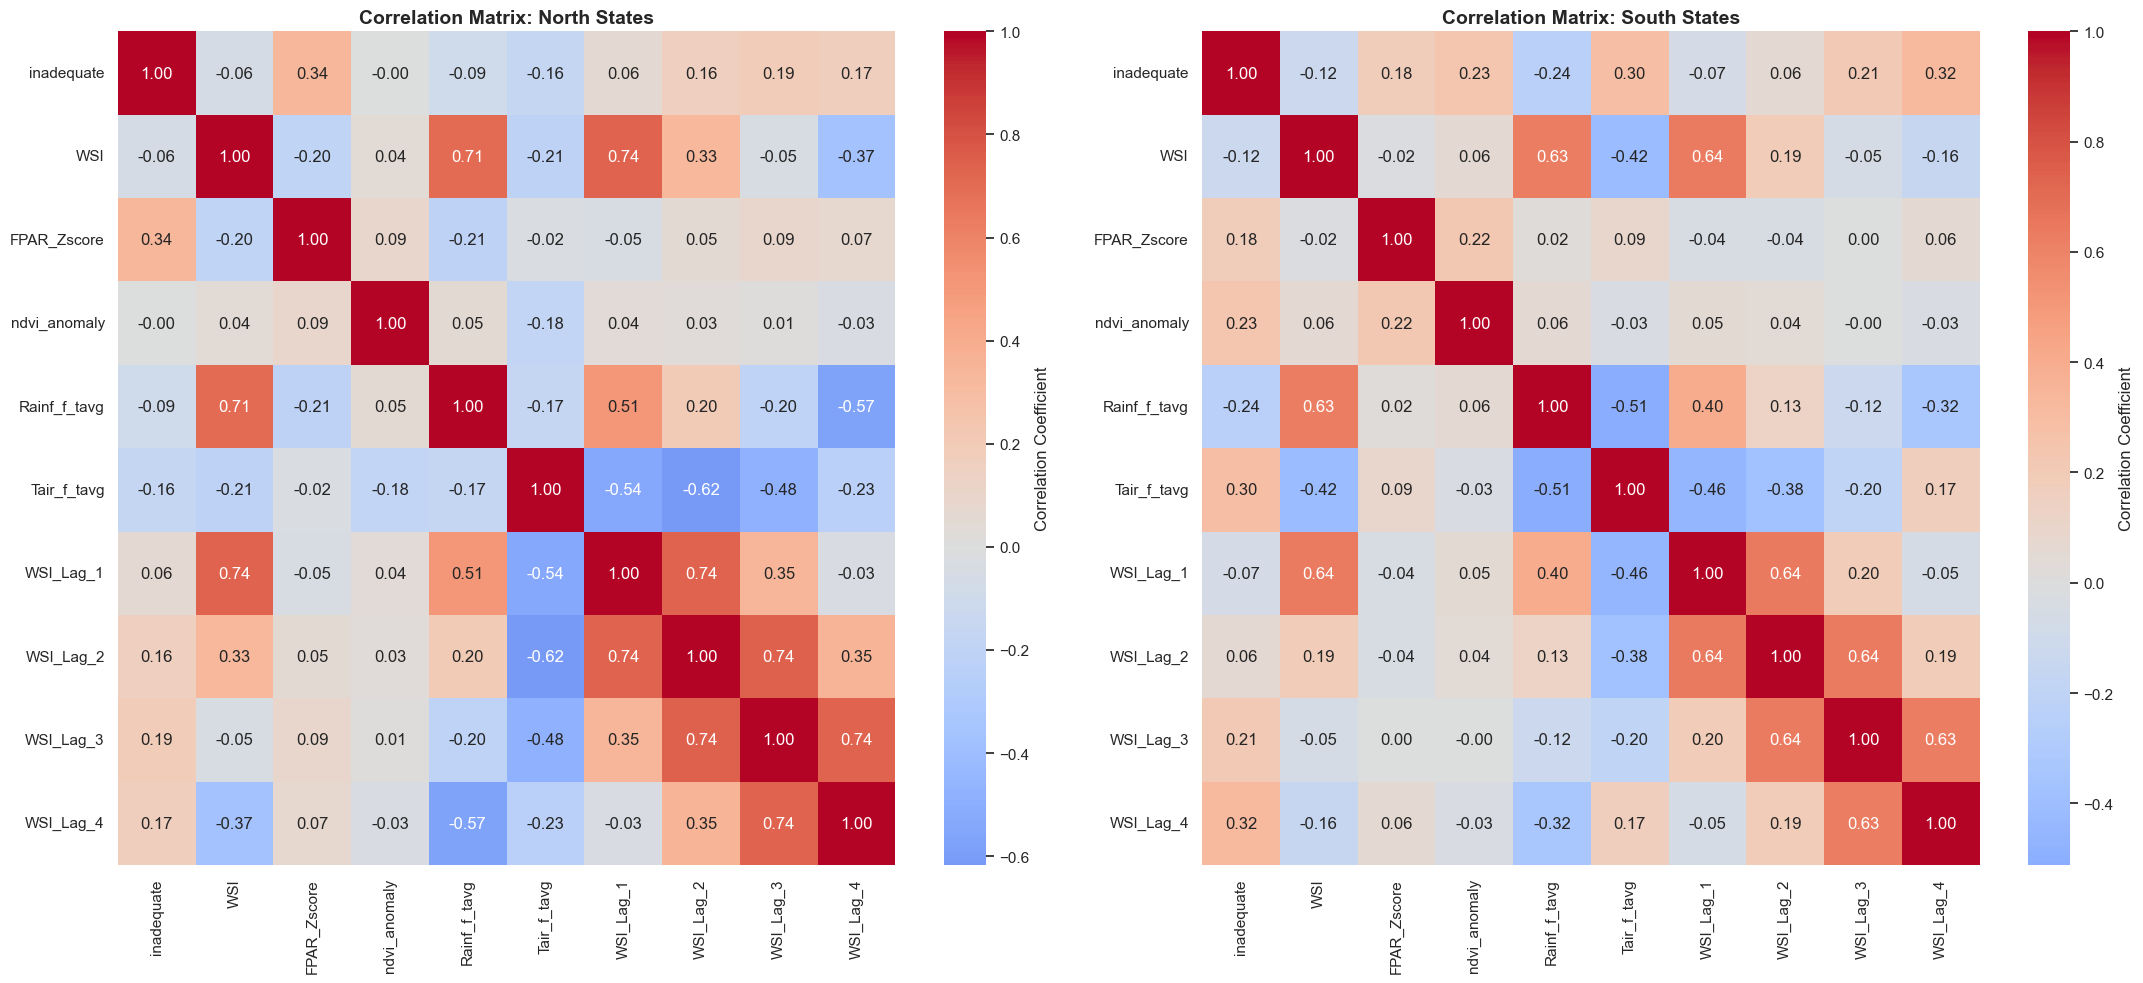

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selection of key variables for the correlation study
# We include the target variable, main climate drivers, and WSI lags
cols_to_study = [
    'inadequate', 'WSI', 'FPAR_Zscore', 'ndvi_anomaly', 
    'Rainf_f_tavg', 'Tair_f_tavg',
    'WSI_Lag_1', 'WSI_Lag_2', 'WSI_Lag_3', 'WSI_Lag_4'
]

# Filtering to keep only the columns actually present in the dataframe
cols_to_study = [col for col in cols_to_study if col in df.columns]

# 2. Function to plot a clean correlation heatmap
def plot_regional_heatmap(df, region_name, ax):
    # Filter data for the specific region
    # We use 'geopolitical_region' column created in the previous steps
    region_data = df[df['geopolitical_region'] == region_name]
    
    if region_data.empty:
        print(f"Warning: No data available for region: {region_name}")
        return

    # Calculate Pearson correlation
    region_corr = region_data[cols_to_study].corr()
    
    # Plotting the heatmap 
    # FIXED: Changed 'cbar_kds' to 'cbar_kws'
    sns.heatmap(region_corr, 
                annot=True, 
                cmap='coolwarm', 
                fmt=".2f", 
                center=0, 
                ax=ax, 
                cbar_kws={'label': 'Correlation Coefficient'})
    
    ax.set_title(f'Correlation Matrix: {region_name} States', fontsize=14, fontweight='bold')

# 3. Execution on a double-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

plot_regional_heatmap(df, 'North', ax1)
plot_regional_heatmap(df, 'South', ax2)

plt.tight_layout()
plt.show()

### 6. Structural Reading of the Correlation Matrix: Latent Dynamics and Mechanisms

While the correlation matrix highlights marginal statistical associations, it does not imply strict causality. However, it is a powerful tool for identifying temporal propagation structures, cascading effects, potential mediating variables, and seasonal confounding.

#### A. Temporal Propagation of the Water Shock (Diagonal Structure)
In both macro-regions, there is a very strong and stable internal correlation between successive lags of the Water Stress Index ($WSI\_Lag\_k$ and $WSI\_Lag_{k+1}$):
* **North:** Correlations of 0.74 between successive lags.
* **South:** Correlations ranging from 0.65 to 0.66 between successive lags.

This diagonal structure demonstrates that water stress is not a discrete shock but a persistent process. A rainfall deficit initiates a cumulative trajectory: rainfall deficit $\rightarrow$ soil moisture stress $\rightarrow$ vegetative stress $\rightarrow$ lower anticipated yields $\rightarrow$ pressure on stocks $\rightarrow$ market price surges $\rightarrow$ deterioration of food security. The matrix thus reveals the strong inertia and climatic memory of the Nigerian agricultural system.

#### B. The Mediating Role of Temperature (North / South Contrast)
* **Northern Dynamics:** Temperature ($Tair\_f\_tavg$) is strongly negatively correlated with future water stress (e.g., -0.62 with $WSI\_Lag\_2$). In this Sahelian environment, temperature acts as an indirect amplifier via the hydrological channel (higher temperatures $\rightarrow$ high evapotranspiration $\rightarrow$ increased water stress $\rightarrow$ delayed food insecurity).
* **Southern Dynamics:** Temperature exhibits a strong direct effect on food insecurity ($r = 0.295$) in addition to its indirect effect. The southern system proves more sensitive to immediate thermal shocks, which can be explained by the nature of local crops (roots and tubers being more prone to rapid spoilage under high heat) alongside logistical and storage constraints.

#### C. FPAR and NDVI: Proxies for Seasonal Phase
The cross-analysis of the vegetative signal in the North shows counter-intuitive correlations (FPAR vs Rainfall at -0.20, FPAR vs Inadequate at 0.29). These results confirm that FPAR is not a causal driver of food insecurity at time $t$. Instead, it acts as a proxy for the seasonal phase: its peak coincides with the rainy season, a period that perfectly matches the agricultural lean season (when household stocks are depleted before new harvests).

#### D. Summary of Regional Structural Disparities

| Feature | North (Seasonal Agricultural System) | South (Integrated Market System) |
| :--- | :--- | :--- |
| **Water shock transmission** | Fast delayed effect (Peak at Lag 3) | Long delayed effect (Peak at Lag 4) |
| **Role of Temperature** | Primarily indirect (amplifies WSI) | Strong direct and indirect effects |
| **Vegetative Signals** | FPAR acts as a seasonality proxy | NDVI is slightly more informative |
| **Nature of vulnerability** | Driven by the local production cycle | Strongly mediated by markets and inter-regional flows |



#### E. Implications for Predictive Modeling (Phase 4)
These latent dynamics dictate several methodological constraints for the machine learning phase:
1. **Handling Multicollinearity:** The high correlation between $WSI\_Lags$ will penalize the stability of a classic linear regression (OLS). It will be necessary to leverage ensemble models robust to collinearity (such as Random Forest or XGBoost), or to perform dimensionality reduction (PCA on Lags) or regularization (Lasso/Ridge).
2. **Asymmetric Feature Selection:** Since instantaneous climate variables (Lag 0) provide almost no informative value in the North, predictive modeling for this area must rely heavily on lagged variables. Conversely, the feature space for the South must incorporate immediate thermal shocks.
3. **Causal Perspectives:** To move beyond the analysis of marginal correlations and isolate the specific effect of each variable, more structural modeling frameworks (Granger causality tests, VAR models, or panel regressions controlling for seasonal fixed effects) should be considered for future developments.

# Phase 3 : Draft

In [34]:
# --- PHASE 3 - STEP 1: Temporal Alignment & Target Prep ---

# 1. S'assurer que la colonne 'time' est au bon format
df['time'] = pd.to_datetime(df['time'])

# 2. Création d'un index complet (tous les mois pour tous les États)
# On définit la plage de dates du début à la fin du dataset
all_months = pd.date_range(start=df['time'].min(), end=df['time'].max(), freq='MS')
all_states = df['NAME_1'].unique()

# On crée un DataFrame pivot avec toutes les combinaisons possibles (État x Mois)
multi_index = pd.MultiIndex.from_product([all_states, all_months], names=['NAME_1', 'time'])
full_df = pd.DataFrame(index=multi_index).reset_index()

# 3. Fusion avec tes données existantes
# On passe de tes données actuelles à un dataset "continu"
df_continuous = pd.merge(full_df, df, on=['NAME_1', 'time'], how='left')

# 4. On ré-applique le mapping des régions (car les nouvelles lignes n'ont pas encore l'info)
df_continuous['geopolitical_region'] = df_continuous['NAME_1'].apply(
    lambda x: 'North' if x in zones['North'] else 'South'
)

print(f"Nombre de lignes avant : {len(df)}")
print(f"Nombre de lignes après réindexation : {len(df_continuous)}")
print(f"Exemple de mois manquant (Mars 2024) : \n", 
      df_continuous[df_continuous['time'] == '2024-03-01'][['time', 'NAME_1', 'inadequate']].head(3))

# On remplace l'ancien df par le nouveau pour la suite
df = df_continuous

Nombre de lignes avant : 973
Nombre de lignes après réindexation : 1080
Exemple de mois manquant (Mars 2024) : 
          time   NAME_1  inadequate
14 2024-03-01     Abia         NaN
50 2024-03-01    Abuja         NaN
86 2024-03-01  Adamawa         NaN


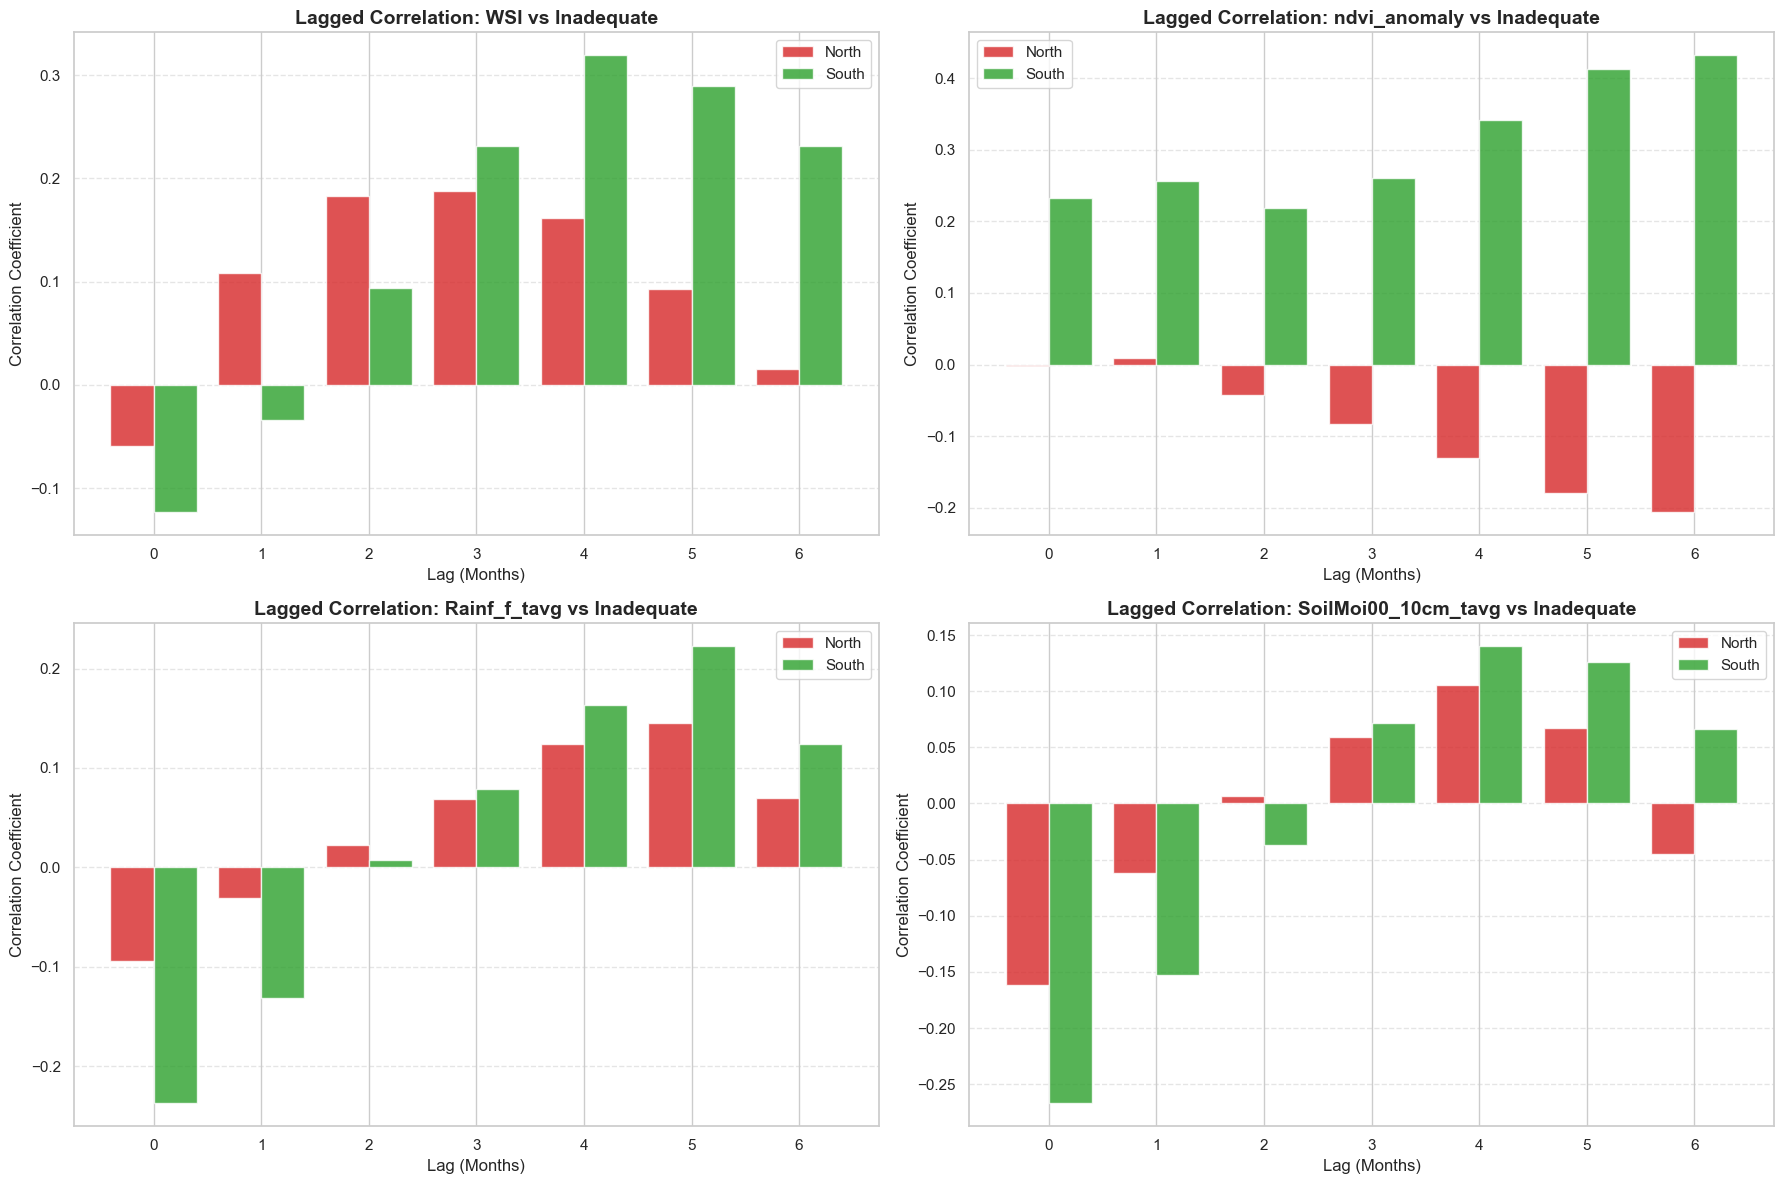

In [35]:
# --- PHASE 3 - : Multi-Feature Lagged Correlations ---

features_to_test = ['WSI', 'ndvi_anomaly', 'Rainf_f_tavg', 'SoilMoi00_10cm_tavg']
max_lag = 6

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_test):
    lags = range(max_lag + 1)
    
    # Calcul pour le Nord
    corrs_n = [df[df['geopolitical_region'] == 'North']['inadequate'].corr(
               df[df['geopolitical_region'] == 'North'][feature].shift(l)) for l in lags]
    
    # Calcul pour le Sud
    corrs_s = [df[df['geopolitical_region'] == 'South']['inadequate'].corr(
               df[df['geopolitical_region'] == 'South'][feature].shift(l)) for l in lags]
    
    # Plotting
    axes[i].bar([l-0.2 for l in lags], corrs_n, width=0.4, label='North', color='#d62728', alpha=0.8)
    axes[i].bar([l+0.2 for l in lags], corrs_s, width=0.4, label='South', color='#2ca02c', alpha=0.8)
    
    axes[i].set_title(f'Lagged Correlation: {feature} vs Inadequate', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Lag (Months)')
    axes[i].set_ylabel('Correlation Coefficient')
    axes[i].set_xticks(lags)
    axes[i].legend()
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Livelihood Zones

In [36]:
#Incorporating Livelihood Zones  ---
import pandas as pd

# 1. Charger le fichier d'intersection Admin 2 / LHZ
lhz_df = pd.read_csv('../data/processed/LHZ_admin2_intersection.csv')

# 2. Trouver la Livelihood Zone dominante pour chaque État (NAME_1)
# On groupe par État et par Livelihood Zone, et on somme les surfaces d'intersection
dominant_lhz = lhz_df.groupby(['NAME_1', 'LZNAMEEN'])['intersect_area'].sum().reset_index()

# On trie pour avoir la plus grande surface d'abord, puis on garde le premier (le dominant)
dominant_lhz = dominant_lhz.sort_values(['NAME_1', 'intersect_area'], ascending=[True, False])
dominant_lhz = dominant_lhz.drop_duplicates(subset='NAME_1', keep='first')

# On renomme pour que ce soit propre
dominant_lhz = dominant_lhz[['NAME_1', 'LZNAMEEN']].rename(columns={'LZNAMEEN': 'dominant_livelihood_zone'})

# 3. Correction des noms d'États pour que la jointure soit parfaite

dominant_lhz['NAME_1'] = dominant_lhz['NAME_1'].replace({'FederalCapitalTerritory': 'Federal Capital Territory', 'AkwaIbom': 'Akwa Ibom', 'CrossRiver': 'Cross River'})

# 4. Fusion avec ton DataFrame principal (df)
df = df.merge(dominant_lhz, on='NAME_1', how='left')

print("Exemple de mapping Livelihood Zone :")
print(df[['NAME_1', 'geopolitical_region', 'dominant_livelihood_zone']].drop_duplicates().head(5))

# 5. Sauvegarde définitive du DataFrame enrichi
df.to_csv('../data/processed/NIGERIA_WFP_ENGINEERED.csv', index=False)
print("Fichier NIGERIA_WFP_ENGINEERED.csv mis à jour avec les Livelihood Zones.")

Exemple de mapping Livelihood Zone :
        NAME_1 geopolitical_region  \
0         Abia               South   
36       Abuja               North   
72     Adamawa               North   
108  Akwa Ibom               South   
144     Bauchi               North   

                              dominant_livelihood_zone  
0    South-east cassava, cereals, and oil palm with...  
36                                                 NaN  
72   Central sorghum, maize, groundnuts, cowpeas, a...  
108  South-east cassava, cereals, and oil palm with...  
144  Central sorghum, maize, groundnuts, cowpeas, a...  
Fichier NIGERIA_WFP_ENGINEERED.csv mis à jour avec les Livelihood Zones.


C:\Users\valen\AppData\Local\Temp\ipykernel_744\2296768.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


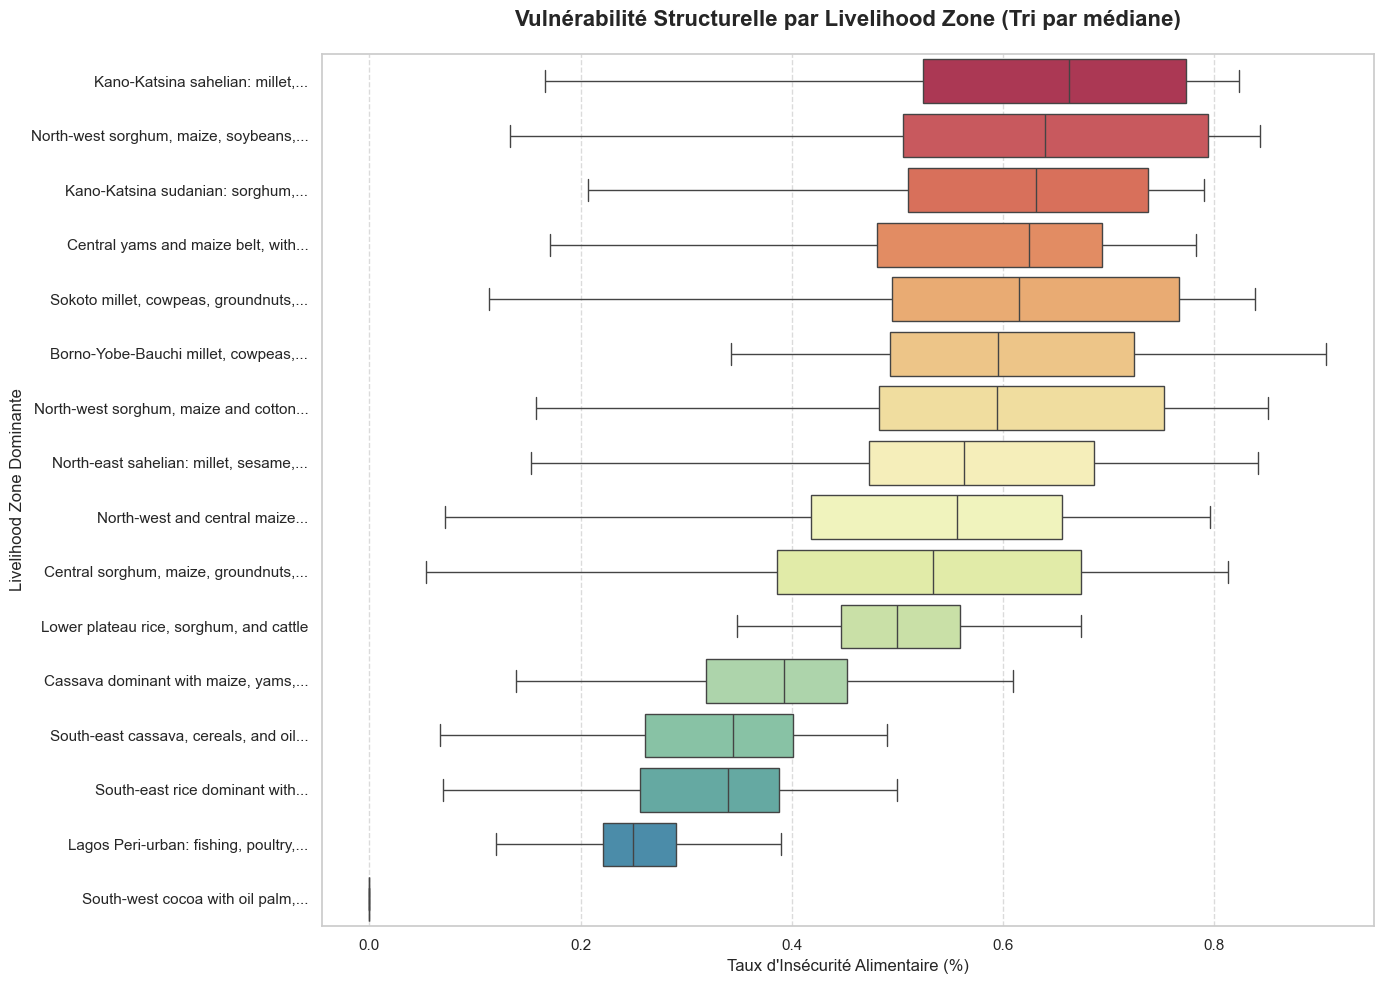


--- TEST STATISTIQUE (ANOVA) ---
Hypothèse Nulle (H0) : La moyenne de l'insécurité alimentaire est identique dans toutes les Livelihood Zones.
Statistique F : 38.56
P-value       : 2.84e-86
Conclusion    : H0 rejetée. Le type de zone agraire explique une part statistiquement significative de la faim.


In [40]:
# --- EXPLORATION DES LIVELIHOOD ZONES (ANOVA & Distributions) ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import textwrap

# 1. Chargement des données
filepath = '../data/processed/NIGERIA_WFP_ENGINEERED.csv'
df = pd.read_csv(filepath)

# On s'assure que la colonne existe et on retire les valeurs manquantes pour l'analyse
if 'dominant_livelihood_zone' in df.columns:
    analysis_df = df.dropna(subset=['dominant_livelihood_zone', 'inadequate']).copy()
    
    # 2. Raccourcir les noms des zones pour l'affichage graphique
    analysis_df['lhz_short'] = analysis_df['dominant_livelihood_zone'].apply(
        lambda x: textwrap.shorten(str(x), width=40, placeholder="...")
    )
    
    # Tri des zones par la médiane de l'insécurité alimentaire
    order = analysis_df.groupby('lhz_short')['inadequate'].median().sort_values(ascending=False).index
    
    # 3. Visualisation : Boxplot horizontal
    plt.figure(figsize=(14, 10))
    sns.boxplot(
        data=analysis_df,
        y='lhz_short',
        x='inadequate',
        order=order,
        palette='Spectral',
        showfliers=False
    )
    
    plt.title("Vulnérabilité Structurelle par Livelihood Zone (Tri par médiane)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Taux d'Insécurité Alimentaire (%)", fontsize=12)
    plt.ylabel("Livelihood Zone Dominante", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 4. Test Statistique (ANOVA)
    # Préparation des groupes pour le test de Fisher
    groups = [group['inadequate'].values for name, group in analysis_df.groupby('dominant_livelihood_zone')]
    f_stat, p_value = stats.f_oneway(*groups)
    
    print("\n--- TEST STATISTIQUE (ANOVA) ---")
    print("Hypothèse Nulle (H0) : La moyenne de l'insécurité alimentaire est identique dans toutes les Livelihood Zones.")
    print(f"Statistique F : {f_stat:.2f}")
    print(f"P-value       : {p_value:.2e}")
    
    if p_value < 0.05:
        print("Conclusion    : H0 rejetée. Le type de zone agraire explique une part statistiquement significative de la faim.")
    else:
        print("Conclusion    : Impossible de rejeter H0. La zone agraire ne semble pas discriminante statiquement.")
else:
    print("La colonne 'dominant_livelihood_zone' n'a pas été trouvée dans le dataset.")

In [41]:
# --- EXTRACTION TEXTUELLE DES STATISTIQUES PAR LHZ ---

# 1. Calcul des statistiques descriptives par Livelihood Zone
lhz_stats = df.groupby('dominant_livelihood_zone')['inadequate'].agg([
    'count', 
    'mean', 
    'median', 
    'std', 
    'min', 
    'max'
]).round(3)

# 2. Calcul de l'Écart Interquartile (IQR) pour mesurer la volatilité spécifique
def get_iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

lhz_stats['IQR'] = df.groupby('dominant_livelihood_zone')['inadequate'].apply(get_iqr).round(3)

# 3. Tri par médiane décroissante (comme sur ton boxplot)
lhz_stats = lhz_stats.sort_values(by='median', ascending=False)

print("=== STATISTIQUES DES LIVELIHOOD ZONES (Inadequate Food Consumption) ===")
print(lhz_stats.to_markdown())

# Petit bonus : Top 3 des zones les plus volatiles (plus haut IQR)
print("\n--- ZONES LES PLUS VOLATILES (Fortes variations saisonnières/chocs) ---")
print(lhz_stats.sort_values(by='IQR', ascending=False).head(3)[['median', 'IQR']].to_markdown())

=== STATISTIQUES DES LIVELIHOOD ZONES (Inadequate Food Consumption) ===
| dominant_livelihood_zone                                                         |   count |   mean |   median |     std |   min |   max |   IQR |
|:---------------------------------------------------------------------------------|--------:|-------:|---------:|--------:|------:|------:|------:|
| Kano-Katsina sahelian: millet, sorghum, sesame, and livestock                    |      35 |  0.601 |    0.662 |   0.204 | 0.12  | 0.823 | 0.248 |
| North-west sorghum, maize, soybeans, and rice                                    |      35 |  0.617 |    0.64  |   0.199 | 0.133 | 0.844 | 0.289 |
| Kano-Katsina sudanian: sorghum, maize, rice, and groundnuts                      |      35 |  0.599 |    0.631 |   0.158 | 0.207 | 0.79  | 0.227 |
| Central yams and maize belt, with cassava, rice, and soybeans                    |      35 |  0.581 |    0.624 |   0.156 | 0.171 | 0.783 | 0.213 |
| Sokoto millet, cowpeas, groundnu



### Structural Vulnerability Analysis (Livelihood Zones)
To refine our predictive model, we analyzed the impact of **Livelihood Zones (LHZ)** on food insecurity. The objective was to determine if the "type" of agricultural system acts as a structural floor for hunger levels.

**Key Findings:**
* **ANOVA Results:** The analysis of variance yielded a **F-statistic of 38.56** and an extremely low **p-value ($2.84 \times 10^{-86}$)**. This statistically proves that the Livelihood Zone is a primary determinant of food insecurity in Nigeria.
* **The North-South Divide:** There is a clear "Structural Gap." Northern cereal-based zones (e.g., *Kano-Katsina Sahelian*) show median inadequate consumption above **60%**, whereas Southern cassava-based zones remain below **40%**.
* **Sensitivity to Shocks:** The highest volatility (measured by Interquartile Range) is found in the **North-West sorghum and maize belts (IQR = 0.289)**. These areas are "climate-sensitive," meaning they are the most likely to react sharply to rainfall deficits ($WSI$).





# Naive Seasonal Baseline

In [38]:
# --- PHASE 3 - STEP 4: Naive Seasonal Baseline ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. S'assurer que le DataFrame est bien trié chronologiquement pour chaque État
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['NAME_1', 'time'])

# 2. Création de la prédiction Baseline : la valeur d'il y a 12 mois (saisonnalité pure)
df['baseline_pred'] = df.groupby('NAME_1')['inadequate'].shift(12)

# 3. Évaluation des performances 
# On retire les lignes où la prédiction ou la vraie valeur est NaN
eval_df = df.dropna(subset=['baseline_pred', 'inadequate']).copy()

# 4. Calcul des scores (Global)
mae_total = mean_absolute_error(eval_df['inadequate'], eval_df['baseline_pred'])
rmse_total = np.sqrt(mean_squared_error(eval_df['inadequate'], eval_df['baseline_pred']))

print(f"--- Baseline Model Performance (Naive Seasonal y_t = y_{{t-12}}) ---")
print(f"Global MAE  : {mae_total:.4f}")
print(f"Global RMSE : {rmse_total:.4f}")
print("-" * 50)

# 5. Calcul des scores par Région (Nord vs Sud)
for region in ['North', 'South']:
    reg_df = eval_df[eval_df['geopolitical_region'] == region]
    if not reg_df.empty:
        reg_mae = mean_absolute_error(reg_df['inadequate'], reg_df['baseline_pred'])
        print(f"MAE {region} : {reg_mae:.4f}")

--- Baseline Model Performance (Naive Seasonal y_t = y_{t-12}) ---
Global MAE  : 0.1850
Global RMSE : 0.2403
--------------------------------------------------
MAE North : 0.2008
MAE South : 0.1499


## Phase 3 Summary: Exploratory Data Analysis & Baseline Model

### 1. Target Construction and Temporal Alignment
* **Primary Target:** Prevalence of `inadequate` food consumption.
* **Alignment Strategy:** The dataset was reindexed to a strict monthly frequency (2023-2026). Missing survey months (e.g., March 2024) were explicitly preserved as `NaN` to maintain temporal integrity for lag features and avoid synthetic imputation bias.

### 2. Spatial and Agronomic Dynamics (Livelihood Zones)
By integrating FEWS NET Livelihood Zones, we identified the structural drivers of regional disparities:
* **Northern States** (e.g., Adamawa, Bauchi): Dominated by rain-fed, short-cycle crops (*Sorghum, Maize, Cowpeas*). This structural reliance on a single rainy season creates high vulnerability to climate shocks and a pronounced **Lean Season** volatility.
* **Southern States** (e.g., Abia, Akwa Ibom): Dominated by resilient root crops (*Cassava, Yams*) and cash crops (*Oil Palm*). This system provides a stable, year-round food supply, insulating the region from extreme seasonal peaks.

### 3. Climate Shock Transmission (Lagged Correlations)
Cross-Correlation Function (CCF) analysis revealed that food insecurity is a delayed response to environmental stress:
* **North:** The impact of water stress (WSI) peaks at a **3-month lag**, reflecting the rapid depletion of household cereal stocks following a poor harvest.
* **South:** The peak occurs at a **4-month lag**, suggesting that food access is disrupted primarily through delayed supply chain shocks and price propagation rather than direct local crop failure.

### 4. Baseline Model Performance
Before deploying advanced predictive models, a **Naive Seasonal Baseline** was established. This model assumes that food insecurity in month $t$ is identical to the same month in the previous year:
$$\hat{y}_{t} = y_{t-12}$$

**Results (Mean Absolute Error):**
* **Global MAE:** **0.1850** (Reference benchmark)
* **Global RMSE:** 0.2403
* **North MAE:** 0.2008 (Higher error reflects greater instability and susceptibility to exogenous shocks).
* **South MAE:** 0.1499 (Lower error reflects strong, predictable seasonality).

> **Phase 4 Objective:** Any subsequent Machine Learning algorithm (Random Forest, XGBoost) must achieve a Global MAE strictly below **0.1850** to demonstrate predictive value beyond simple historical seasonality.